In [ ]:
%pip install puremacro


# Quarterly National Accounts — three measurements of one GDP

**A statistical office measures GDP three separate ways, from three separate
source systems. What do you do when they disagree?**

Fetching a national accounts panel is the easy part. What follows the fetch is
where the work is, and where a notebook usually starts hand-rolling: the
volumes of different countries are referenced to different base years and are
not comparable as levels; the accounting identity closes exactly in current
prices but visibly fails in volume terms; and real GDP growth cannot be added
up from its components at all. This notebook walks the four transforms
`puremacro.fetch` provides for that work — `qna_countries`, `qna_rebase`,
`qna_identity`, `qna_contributions` — on a frozen six-country panel carrying
all three approaches. Everything below runs offline.

## The method in math

**The three approaches.** The same quantity, measured three ways:

$$ Y = \underbrace{C + G + I + X - M}_{\text{expenditure}}
     = \underbrace{\textstyle\sum_j VA_j + (D21 - D31) + YA1}_{\text{output}}
     = \underbrace{D1 + B2A3G + (D2 - D3)}_{\text{income}} $$

The expenditure approach adds up who bought the output; the output approach
adds up the value added of the industries that made it, plus taxes less
subsidies on products; the income approach adds up what was paid to the
factors that produced it — compensation of employees $D1$, gross operating
surplus and mixed income $B2A3G$, and taxes less subsidies on production and
imports.

**Why the residuals are not all the same thing.** In *current prices* the
expenditure identity is an accounting fact, and most offices force its
residual to zero. What is left over is a **statistical discrepancy** — and on
seasonally adjusted data it also carries the non-additivity that adjusting
each series independently introduces, which shows up as a sign-alternating
residual rather than a drift.

In *volume* terms the identity genuinely does not hold. Chain-linked volumes
are a Laspeyres chain: each quarter's growth uses the previous period's
prices, so the levels are not additive away from the reference year, and the
gap widens the further you go from it. That is not a data error. It is the
reason growth is **decomposed** rather than added up:

$$ g_t = \sum_i \omega_{i,t-1}\, g_{i,t}, \qquad
   \omega_{i,t-1} = \frac{P_{i,t-1} Q_{i,t-1}}{P_{t-1} Q_{t-1}} $$

— the weight is the component's share in **previous-period current prices**,
which is why a contribution calculation needs the nominal panel and the volume
panel at the same time. Imports enter with a negative sign.

**Why each identity must be scored inside its own flow.** The OECD publishes
GDP separately in each of the three dataflows, from different source tables,
and the three figures do not always agree. Scoring the output components
against the *expenditure* flow's GDP would charge that disagreement to the
components. So `gdp_output` and `gdp_income` are carried as their own columns,
each identity is scored against its own, and the disagreement between flows is
reported separately as `crossflow_output` / `crossflow_income`.

## Setup — a frozen six-country panel with all three approaches

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from puremacro.fetch import qna_contributions, qna_identity, qna_rebase
from puremacro.replication._data import load_csv

# Frozen by `tools/gen_notebook_data_qna40.py` from
# `qna_panel(..., output=True, income=True, real=True)`. A live panel and a
# frozen one behave identically here: none of the transforms touch the network.
flat = load_csv("qna40_panel")
panel = (flat.assign(date=pd.to_datetime(flat["date"]))
             .set_index(["code", "date"])
             .sort_index())

# qna_meta() reads panel.attrs, which no CSV can carry, so the provenance
# travels as its own frozen file.
meta = load_csv("qna40_meta")

print(f"panel: {panel.shape[0]} quarters x {panel.shape[1]} columns")
print(f"countries: {', '.join(sorted(panel.index.get_level_values('code').unique()))}")
print(meta[["code", "currency", "price_base", "price_ref_year", "n_obs"]].to_string(index=False))

panel: 756 quarters x 75 columns
countries: DEU, ESP, ITA, JPN, MEX, USA
code currency price_base  price_ref_year  n_obs
 DEU      EUR          L          2020.0    126
 ESP      EUR          L          2020.0    126
 ITA      EUR          L          2020.0    125
 JPN      JPY          L          2020.0    126
 MEX      MXN          Q          2018.0    125
 USA      USD          L          2017.0    126


**Read the `price_ref_year` column.** Each country's volumes are referenced to
that country's own base year — the OECD does not impose a common one. Deflator
columns are therefore *indices against different years*, and comparing them
across countries as levels compares nothing.

## One price reference year — `qna_rebase`

`qna_rebase` puts every country on one reference year by scaling each
country's deflator and rescaling its volumes by the same factor, so
`nominal = real x deflator / 100` still holds exactly, component by component.
This is a re-*referencing*: one scalar per country, leaving every growth rate
and every chain link untouched. It is not a re-basing, which a published
chain-linked volume does not let you do at all.

In [2]:
rebased = qna_rebase(panel, 2020)

q = "2020-01-01"
before = panel.xs(q, level="date")["gdp_defl"]
after = rebased.xs(q, level="date")["gdp_defl"]
comparison = pd.DataFrame({
    "base year": meta.set_index("code")["price_ref_year"].astype(int),
    "deflator at 2020Q1, as published": before,
    "after qna_rebase(2020)": after,
})
print(comparison.to_string(float_format=lambda v: f"{v:8.2f}"))

# The identity survives the transform, which is the point of doing it this way.
resid = (rebased["gdp"] - rebased["gdp_real"] * rebased["gdp_defl"] / 100).abs()
rel = (resid / rebased["gdp"]).groupby(level="code").max()
print("\nmax |nominal - real x deflator/100| / nominal, after rebasing:")
print(rel.to_string(float_format=lambda v: f"{v:.2e}"))

      base year  deflator at 2020Q1, as published  after qna_rebase(2020)
code                                                                     
DEU        2020                             99.84                   99.83
ESP        2020                             99.74                   99.75
ITA        2020                             98.99                   98.98
JPN        2020                             99.72                   99.75
MEX        2018                            107.94                   98.86
USA        2017                            105.03                   99.69

max |nominal - real x deflator/100| / nominal, after rebasing:
code
DEU   5.97e-06
ESP   4.67e-06
ITA   5.21e-06
JPN   1.06e-05
MEX   4.57e-06
USA   4.37e-06


**Reading the output.** The countries already referenced to 2020 barely move;
the two that were not — the ones whose published deflator at 2020Q1 is far
from 100 — are pulled onto the common year. The residual column confirms the
accounting identity still holds afterwards, to the precision of the frozen
snapshot's six significant digits.

## Scoring the identities — `qna_identity`

Each approach is scored against its **own** flow's GDP, and the residuals are
reported separately rather than netted into one number.

In [3]:
ident = qna_identity(panel)
columns = ["nominal_absmax", "real_last", "output_absmax", "crossflow_output",
           "income_absmax", "crossflow_income"]
print("all figures are percent of GDP\n")
print(ident[columns].to_string(float_format=lambda v: f"{v:8.4f}"))

all figures are percent of GDP

      nominal_absmax  real_last  output_absmax  crossflow_output  income_absmax  crossflow_income
code                                                                                             
DEU           1.5124     1.2216         1.5120            0.0000         0.0005            1.7664
ESP           0.0000     0.1575         0.0000            0.0000         0.0000            0.0000
ITA           0.0004     0.0554         0.0003            0.0000         0.0005            0.0000
JPN           0.0005     0.3293         0.0006            0.6120            NaN            0.0000
MEX           5.3584     3.8951         0.0006            2.6175         0.0003            2.5144
USA           0.0004     0.0327            NaN               NaN         1.9980            0.0000


**Reading the output.** Four different things are visible in that table, and
only one of them is a data problem:

- **`nominal_absmax`** is the statistical discrepancy in current prices. Where
  it is exactly zero the office has forced it to zero — a presentation choice,
  not better measurement. Where it is not, seasonal adjustment is a large part
  of the reason: adjusting each series independently means the adjusted
  components no longer sum to the adjusted total.
- **`real_last`** is the chain-linking gap in the most recent quarter. It is
  not an error and it does not shrink with better data; it grows with distance
  from the reference year, which is why the section below decomposes growth
  instead of adding up volumes.
- **`crossflow_output` / `crossflow_income`** are the disagreements *between*
  flows — the same country's GDP, measured two ways, from two source systems.
  Charging this to an approach's own components would be a mistake, so it gets
  its own column.
- **A `NaN` means the country does not publish that approach at all**, which
  is different from publishing it with a large residual. The United States is
  absent from the OECD's by-activity output flow entirely: the US industry
  accounts are a separate BEA release.

The United States' `income_absmax` is the one residual with a name and a
literature behind it: the **GDP–GDI statistical discrepancy**, which Nalewaik
(2010) shows is informative about the business cycle in its own right rather
than being noise to be averaged away.

## Hero figure — contributions to real GDP growth

`qna_contributions` decomposes real GDP growth into component contributions
using previous-period nominal weights: the calculation chain-linking requires,
and one that needs all three products of a QNA build at once — volumes for the
growth rate, current prices for the weight. Whatever the weights fail to
account for is returned as an explicit `residual` column rather than smeared
over the components.

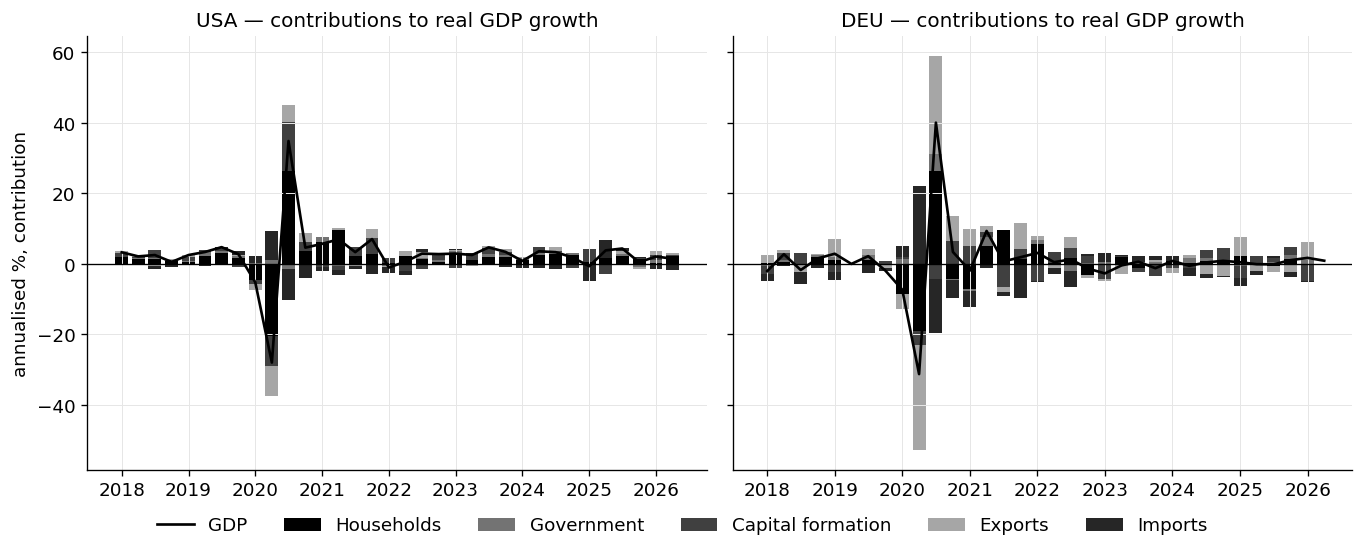

United States, most recent four quarters (annualised %):
            cons_hh  cons_gov  capform  exports  imports     gdp  residual
date                                                                      
2025-07-01     2.36      0.36     0.03     1.01     0.62    4.38     -0.01
2025-10-01     1.30     -0.98     0.39    -0.35     0.13    0.48     -0.01
2026-01-01     0.37      0.70     1.40     1.12    -1.50    2.09     -0.01
2026-04-01     2.13     -0.11     0.51     0.49    -1.51    1.50     -0.01


In [4]:
contrib = qna_contributions(panel, annualise=True)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4), sharey=True)
parts = ["cons_hh", "cons_gov", "capform", "exports", "imports"]
labels = ["Households", "Government", "Capital formation", "Exports", "Imports"]
colors = _nbstyle.palette(len(parts))

for ax, code in zip(axes, ["USA", "DEU"]):
    c = contrib.loc[code].loc["2018":].dropna(how="all")
    bottom_pos = np.zeros(len(c))
    bottom_neg = np.zeros(len(c))
    for part, label, color in zip(parts, labels, colors):
        v = c[part].to_numpy()
        base = np.where(v >= 0, bottom_pos, bottom_neg)
        ax.bar(c.index, v, width=70, bottom=base, color=color,
               label=label if code == "USA" else None)
        bottom_pos = bottom_pos + np.where(v >= 0, v, 0.0)
        bottom_neg = bottom_neg + np.where(v < 0, v, 0.0)
    ax.plot(c.index, c["gdp"], color="black", lw=1.6, label="GDP" if code == "USA" else None)
    ax.axhline(0.0, color="black", lw=0.8)
    ax.set_title(f"{code} — contributions to real GDP growth")
    ax.set_xlabel("")

axes[0].set_ylabel("annualised %, contribution")
fig.legend(loc="lower center", ncol=6, frameon=False, bbox_to_anchor=(0.5, -0.06))
fig.tight_layout()
plt.show()

recent = contrib.loc["USA"].dropna(how="all").tail(4)
print("United States, most recent four quarters (annualised %):")
print(recent.to_string(float_format=lambda v: f"{v:7.2f}"))

**Reading the output.** The black line is measured real GDP growth; the bars
are what each component contributed to it. Imports enter negatively by
construction — a quarter where imports fall contributes *positively* to
measured GDP, which is an accounting fact about the identity rather than a
statement about whether importing less is good. The `residual` column is the
part the previous-period weights do not span; it is small, it is reported, and
it is never distributed over the components to make the arithmetic look
tidier than it is. The 2020 bars show the pandemic quarters at annualised
rates, which is the convention US commentary uses and roughly quadruples the
visual amplitude of a quarterly move.

## The labour share, and the adjective that matters

In [5]:
labour_share = (panel["comp_emp"] / panel["gdp"]).groupby(level="code").last()
print("compensation of employees / GDP, most recent quarter:")
print(labour_share.dropna().to_string(float_format=lambda v: f"{v:.1%}"))

compensation of employees / GDP, most recent quarter:
code
DEU   54.2%
ESP   49.2%
ITA   40.1%
JPN   49.0%
MEX   31.2%
USA   50.0%


**This is the *unadjusted* labour share, and the adjective is load-bearing.**
Compensation of employees counts what is paid to *employees*. The income of
the self-employed is not in `comp_emp` at all — it sits inside
`surplus_mixed`, mixed income being precisely the part of the operating
surplus that cannot be split into labour and capital. So a country with a
large self-employed sector reads low here for a reason that has nothing to do
with how its employees are paid. Gollin (2002) is the reference on adjusting
for this, and the spread across these six countries is largely a spread in
self-employment, not in bargaining power.

## Your turn

**Prompts.**

1. *Basic*: rebase to a different year — `qna_rebase(panel, 2015)` — and check
   that `qna_contributions` returns the same numbers. Growth rates are
   invariant to the reference year; if your answer moves, the re-referencing
   was not a re-referencing.
2. *Intermediate*: score the identity on the rebased panel instead of the
   published one. Which residual columns change, and which cannot?
3. *Stretch*: `qna_contributions(panel, annualise=False)` gives quarterly
   rather than annualised rates. Rebuild the figure and compare the visual
   story of 2020 — then decide which convention you would use in a paper, and
   write down why.

In [6]:
# Your turn code block
alt = qna_rebase(panel, 2015)  # ← change this: try 2010, 2015, 2020
same = qna_contributions(alt, annualise=True)
delta = (same["gdp"] - contrib["gdp"]).abs().max()
print(f"max |growth(rebased 2015) - growth(as published)|: {delta:.2e} pp")
print("Re-referencing moves levels, never growth rates.")

max |growth(rebased 2015) - growth(as published)|: 1.42e-13 pp
Re-referencing moves levels, never growth rates.


## How comprehensive is this?

`qna_panel` builds the panel and `qna_countries` asks the SDMX availability
endpoint which reference areas a dataflow actually carries — so a panel can
cover what the source supports rather than a hand-typed list that goes stale.
Country groupings such as `OECD` and `EA20` are dropped by default, because a
panel that silently mixes an aggregate in with its members double-counts
everything it touches.

Coverage is not uniform and the panel says so rather than papering over it:
of the OECD's 49 reference areas, 46 appear in the by-activity output flow and
40 in the income flow, and four of the 46 publish value added in volume terms
only. A country that does not publish an approach reads `NaN`, never a
spurious 100% gap.

Two of the fifteen value-added columns are memo items rather than addends —
`va_mfg` sits inside `va_ind`, and `va_services` aggregates seven columns
already listed — so `QNA_VA_ADDITIVE` names the ten that actually sum to the
total. Adding every `va_*` column would count about a third of the economy
twice.